In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import spectrogram, welch
import scipy.io.wavfile as wav

### Exploratory Analysis of Audios

In [2]:
# begin with loading and normalizing audio
sample_rate_crowd, audio_crowd = wav.read("crowd_noise.wav")
sample_rate_ac, audio_ac = wav.read('ac_noise.wav')
sample_rate_blender, audio_blender = wav.read("blender_noise.wav")

In [15]:
from IPython.display import display, Audio

print("AC Noise:")
display(Audio(audio_ac, rate=sample_rate_ac))

print("Blender Noise:")
display(Audio(audio_blender, rate=sample_rate_blender))


AC Noise:


Blender Noise:


In [16]:
# Normalize all audios

# convert to mono
if audio_ac.ndim > 1:
    audio_ac = audio_ac.mean(axis=1)
if audio_blender.ndim > 1:
    audio_blender = audio_blender.mean(axis=1)

# normalize all samples
audio_ac = audio_ac.astype(np.float32)
audio_blender = audio_blender.astype(np.float32)


audio_ac /= np.max(np.abs(audio_ac))
audio_blender /= np.max(np.abs(audio_blender))


In [17]:
import matplotlib.pyplot as plt
# time axes for each audio

t_ac = np.linspace(0, len(audio_ac) / sample_rate_ac, len(audio_ac))
t_blender = np.linspace(0, len(audio_blender) / sample_rate_blender, len(audio_blender))


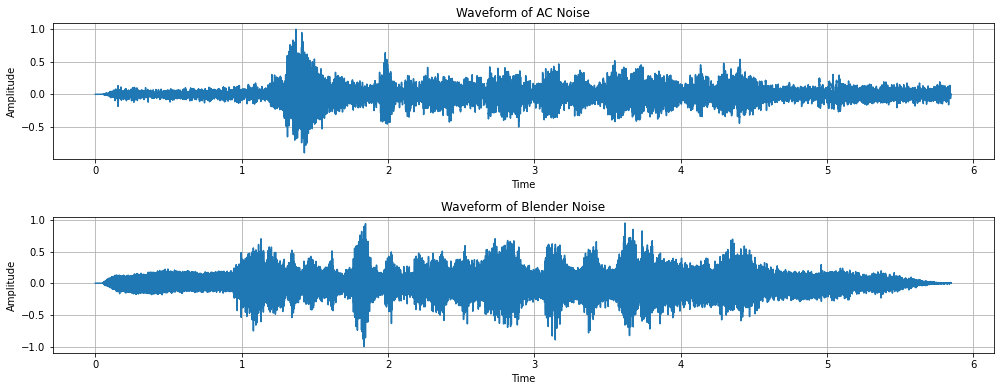

In [18]:
# plot all plots together
plt.figure(figsize=(14, 8))


# For AC Noise
plt.subplot(3, 1, 2)
plt.plot(t_ac, audio_ac)
plt.title("Waveform of AC Noise")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True)

# For Blender Noise
plt.subplot(3, 1, 3)
plt.plot(t_blender, audio_blender)
plt.title("Waveform of Blender Noise")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

#### The time domain waveforms of speech in noise signals highlight the difference that background environments make in speech clarity.
#### The AC noise in contrast is more stationary and low in amplitude, resulting in a cleaner speech profile with minimal waveform distortion.
#### The blender noise presents high amplitude rhythmic interference that overlaps with both voiced and unvoiced speech segments causing more agressive masking across time

In [19]:
# spectrogram computation
f_ac, t_ac_spec, Sxx_ac = spectrogram(audio_ac, fs=sample_rate_ac, nperseg=1024, noverlap=512)
f_blender, t_blender_spec, Sxx_blender = spectrogram(audio_blender, fs=sample_rate_blender, nperseg=1024, noverlap=512)


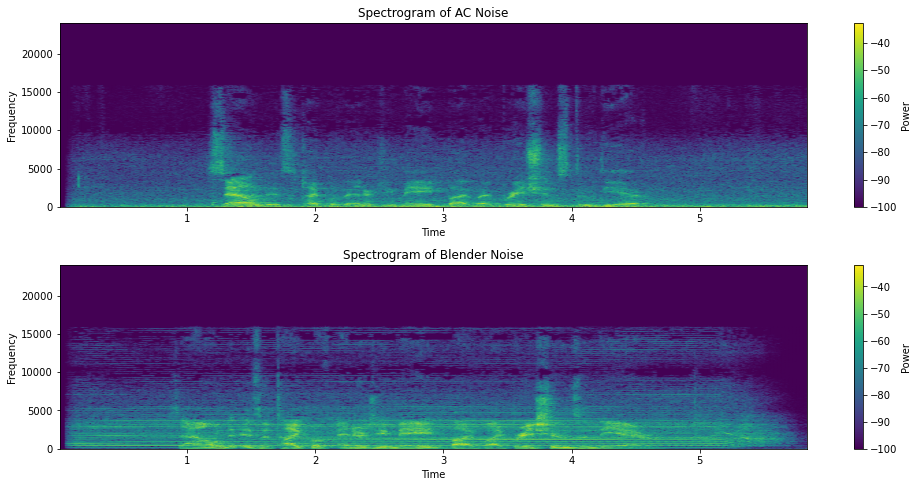

In [20]:
# to plot all 3 spectrograms
plt.figure(figsize=(14, 10))


# ac noise spec
plt.subplot(3, 1, 2)
plt.pcolormesh(t_ac_spec, f_ac, 10*np.log10(Sxx_ac + 1e-10), shading='gouraud')
plt.title("Spectrogram of AC Noise")
plt.ylabel("Frequency")
plt.xlabel("Time")
plt.colorbar(label="Power")
plt.ylim(0, sample_rate_ac/2)

# blender noise spec
plt.subplot(3, 1, 3)
plt.pcolormesh(t_blender_spec, f_blender, 10*np.log10(Sxx_blender + 1e-10), shading='gouraud')
plt.title("Spectrogram of Blender Noise")
plt.ylabel("Frequency")
plt.xlabel("Time")
plt.colorbar(label="Power")
plt.ylim(0, sample_rate_blender/2)

plt.tight_layout()
plt.show()

#### The spectrograms of the noise speech samples provide insight into time frequency overlap between speech and background noise.
#### The ac noise shows a clear low frequency band below 500Hz that is mostly non-overlapping with speech, allowing adaptive filters to attenuate it without corrupting vocal formants
#### Blender noise exhibits a wider spectral spread partially overlapping both voiced and unvoiced components of speech. However, it is relatively consistent power across time can be tracked and supressed adaptively.

In [21]:
# power spectral density
f_ac_psd, Pxx_ac = welch(audio_ac, fs=sample_rate_ac, nperseg=1024)
f_blender_psd, Pxx_blender = welch(audio_blender, fs=sample_rate_blender, nperseg=1024)

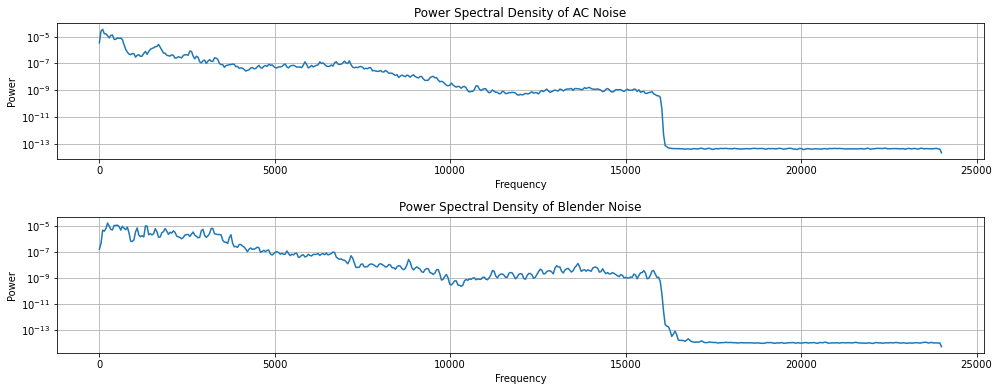

In [22]:
# plotting all 3 PSDs
plt.figure(figsize=(14, 8))


# ac noise psd
plt.subplot(3, 1, 2)
plt.semilogy(f_ac_psd, Pxx_ac)
plt.title("Power Spectral Density of AC Noise")
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.grid(True)

# blender noise psd
plt.subplot(3, 1, 3)
plt.semilogy(f_blender_psd, Pxx_blender)
plt.title("Power Spectral Density of Blender Noise")
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.grid(True)

plt.tight_layout()
plt.show()

#### PSD plots compare the average spectral energy distribution of the three noisy speech signals.
#### AC noise is concetration below 500Hz outside the core frequency range of intelligible speech, allowing selective supression with minial speech degradation.
#### Blender noise has a high spectral energy with semi periodic bumps, suggesting rotational machinery harmonics. Though overlapping with speech it is possible to supress these harmonics if the filter adapts to their stationary pattern

### Beginning work on the Adaptive Filter

In [11]:
import numpy as np

def lms_filter(u, d, M=256, mu=0.01):
    """
    Improved LMS adaptive filter implementation.

    Parameters:
    u : np.ndarray
        Noisy input signal (1D array).
    d : np.ndarray
        Desired signal (clean speech, 1D array).
    M : int
        Number of filter taps (default: 256).
    mu : float
        Learning rate / step size (default: 0.01).

    Returns:
    dhat : np.ndarray
        Filter output (estimated clean speech).
    e : np.ndarray
        Error signal (d - dhat).
    w : np.ndarray
        Final filter weights.
    """
    # Ensure 1D numpy arrays
    u = np.asarray(u).flatten()
    d = np.asarray(d).flatten()

    if u.shape[0] != d.shape[0]:
        raise ValueError("Input signals u and d must have the same length.")

    N = len(u)
    dhat = np.zeros(N)
    e = np.zeros(N)
    w = np.zeros(M)

    # Zero-pad the input for easier frame extraction
    u_padded = np.concatenate((np.zeros(M - 1), u))

    for n in range(N):
        # Efficient forward slice, then reverse
        U = u_padded[n : n + M][::-1]
        dhat[n] = np.dot(w, U)
        e[n] = d[n] - dhat[n]
        w += mu * U * e[n]

    return dhat, e, w



Processing: blender_noise.wav with reference blender_background.wav
MSE: 0.008283
SNR: 2.61 dB
Original Noisy Speech:


LMS Filtered Output:


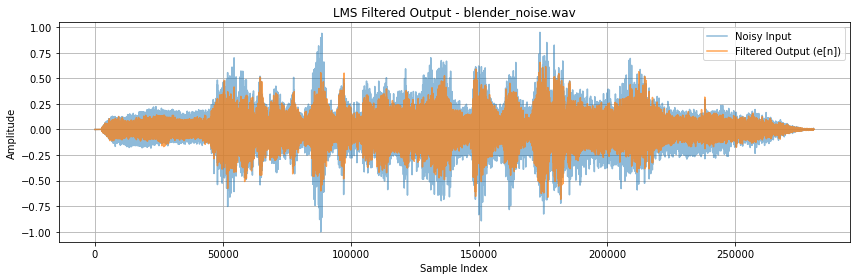


Processing: ac_noise.wav with reference ac_background.wav


/var/folders/2m/jcjlh17n5tzctdvfqpkgtx3w0000gn/T/ipykernel_67064/2147894326.py:25: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_u, noise = wavfile.read(noise_file)


MSE: 0.007921
SNR: 1.07 dB
Original Noisy Speech:


LMS Filtered Output:


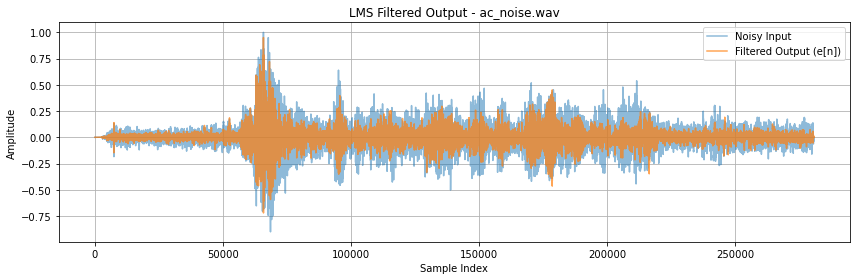

In [12]:
#storage for results
results={}

# test cases: (noisy_speech, noisy_reference)
test_cases = [
    ('blender_noise.wav', 'blender_background.wav'),
    ('ac_noise.wav', 'ac_background.wav'),

]

def compute_mse(d, e):
    return np.mean((d - e) ** 2)

def compute_snr(d, e):
    signal_power = np.mean(d ** 2)
    noise_power = np.mean((d - e) ** 2)
    return 10 * np.log10(signal_power / (noise_power + 1e-10))

for noisy_file, noise_file in test_cases:
    print(f"\nProcessing: {noisy_file} with reference {noise_file}")

    try:
        # loading signals
        fs_d, noisy = wavfile.read(noisy_file)
        fs_u, noise = wavfile.read(noise_file)
        assert fs_d == fs_u, "Sampling rates must match"

        # conversion to mono
        if noisy.ndim > 1:
            noisy = noisy.mean(axis=1)
        if noise.ndim > 1:
            noise = noise.mean(axis=1)

        # normalize
        noisy = noisy.astype(np.float32)
        noise = noise.astype(np.float32)
        noisy /= np.max(np.abs(noisy))
        noise /= np.max(np.abs(noise))

        # trim to shortest length
        min_len = min(len(noisy), len(noise))
        noisy = noisy[:min_len]
        noise = noise[:min_len]

        # applying adaptive filter lms
        dhat, error, weights = lms_filter(noise, noisy, M=256, mu=0.0150)  # u = noise, d = noisy

        # compute metrics
        mse = compute_mse(noisy, error)
        snr = compute_snr(noisy, error)
        print(f"MSE: {mse:.6f}")
        print(f"SNR: {snr:.2f} dB")

        # store results
        results[noisy_file] = {
            "noisy": noisy,
            "noise": noise,
            "output": error,
            "weights": weights,
            "rate": fs_d
        }

        # audios
        print("Original Noisy Speech:")
        display(Audio(noisy, rate=fs_d))
        print("LMS Filtered Output:")
        display(Audio(error, rate=fs_d))

        # plotting outcomes
        plt.figure(figsize=(12, 4))
        plt.plot(noisy, label="Noisy Input", alpha=0.5)
        plt.plot(error, label="Filtered Output (e[n])", alpha=0.7)
        plt.title(f"LMS Filtered Output - {noisy_file}")
        plt.xlabel("Sample Index")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    except Exception as ex:
        print(f"Error processing {noisy_file} with {noise_file}: {ex}")


##### As is quite evident from the outcome of the LMS filter above, there is a noticeable distortion in the speech. Despite this we can also notice that a considerable amount of the background noise, in this case the blender has been removed. The addition of distortion in the speech is attributed to how the LMS Filter works. It minimizes the mean squared error between the filter output and a desired signal and updates its internal weights using a simple gradient based rule.
##### This means that the LMS is essentially blind in that it does not understand speech vs noise, hence cannot 'learn' to prioritize desired speech and filter out undesirable noise. In this case, the blender noise is broadband and shares frequency content with the speech. Since the LMS cannot differentiate between which speech and noise in the signal, it removes parts of the speech that resemble the noise spectrum.

##### Furthermore, the filter has no reference for what is noise and what is speech, which also results in spressions of transients or consonants, which is what causes some of the muffling effect in the speech.

In [13]:
# we now apply the NLMS adaptive filter to the same sounds to see if there is any improvement
import numpy as np

def nlms_filter(u, d, M=256, mu=0.8, epsilon=1e-6, return_all_weights=False):
    """
    Normalized least mean squares (NLMS) adaptive filter.

    parameter:
    u : np.ndarray
        Input (noise reference) signal, shape (N,)
    d : np.ndarray
        Desired signal (noisy speech), shape (N,)
    M : int
        Filter length (number of taps)
    mu : float
        Step size / learning rate (0 < mu <= 1)
    epsilon : float
        Small constant to prevent division by zero
    return_all_weights : bool
        If True, returns W (filter weights at every step)

    Outcome:
    dhat : np.ndarray
        Filter output (estimated noise)
    e : np.ndarray
        Error signal (cleaned speech)
    w or W : np.ndarray
        Final filter weights or full weight evolution (if return_all_weights=True)
    """

    # ensure signals are 1D
    u = np.asarray(u).flatten()
    d = np.asarray(d).flatten()

    if len(u) != len(d):
        raise ValueError("Signals u and d must be the same length.")

    N = len(u)
    dhat = np.zeros(N)
    e = np.zeros(N)
    w = np.zeros(M)

    if return_all_weights:
        W = np.zeros((N, M))

    # pad input with M-1 zeroes
    u_padded = np.concatenate((np.zeros(M - 1), u))

    # NLMS looping
    for n in range(N):
        U = u_padded[n : n + M][::-1]  # Recent input window (M-tap)
        dhat[n] = np.dot(w, U)
        e[n] = d[n] - dhat[n]

        norm_factor = epsilon + np.dot(U, U)
        w += (mu / norm_factor) * U * e[n]

        if return_all_weights:
            W[n] = w.copy()

    if return_all_weights:
        return dhat, e, W
    return dhat, e, w



Processing: blender_noise.wav with reference blender_background.wav
MSE: 0.014576
SNR: 0.15 dB
Noisy Speech:


NLMS Filtered Output:


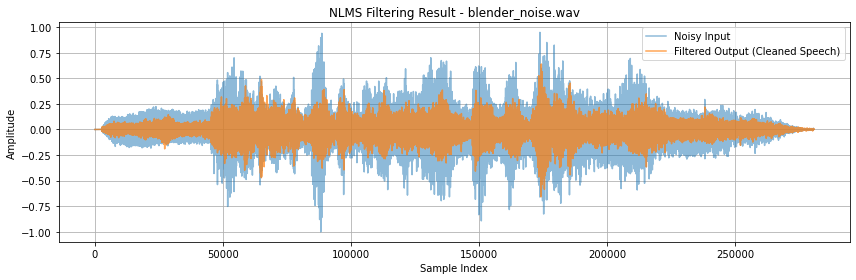


Processing: ac_noise.wav with reference ac_background.wav


/var/folders/2m/jcjlh17n5tzctdvfqpkgtx3w0000gn/T/ipykernel_67064/2400426054.py:20: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs_u, u = wavfile.read(noise_file)


MSE: 0.010321
SNR: -0.08 dB
Noisy Speech:


NLMS Filtered Output:


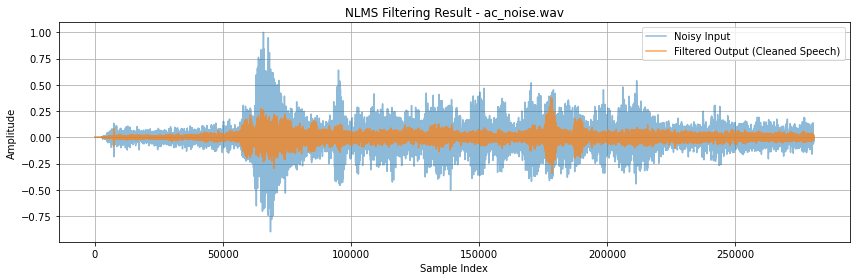

In [14]:
# implementation
test_cases = [
    ("blender_noise.wav", "blender_background.wav"),
    ('ac_noise.wav', 'ac_background.wav')
]

def compute_mse(d, e):
    return np.mean((d - e) ** 2)

def compute_snr(d, e):
    signal_power = np.mean(d ** 2)
    noise_power = np.mean((d - e) ** 2)
    return 10 * np.log10(signal_power / (noise_power + 1e-10))

for noisy_file, noise_file in test_cases:
    print(f"\nProcessing: {noisy_file} with reference {noise_file}")

    # load audio
    fs_d, d = wavfile.read(noisy_file)
    fs_u, u = wavfile.read(noise_file)

    assert fs_d == fs_u, 'sampling rates must match'

    # convert stereo to mono if required
    if d.ndim > 1:
        d = d.mean(axis=1)
    if u.ndim > 1:
        u = u.mean(axis=1)

    # normalize both signals
    d = d.astype(np.float32)
    u = u.astype(np.float32)
    d /= np.max(np.abs(d))
    u /= np.max(np.abs(u))

    # match length
    min_len = min(len(u), len(d))
    d = d[:min_len]
    u = u[:min_len]

    # apply nlms
    dhat, e, w = nlms_filter(u, d, M=256, mu=0.9)

    # compute metrics
    mse = compute_mse(d, e)
    snr = compute_snr(d, e)
    print(f"MSE: {mse:.6f}")
    print(f"SNR: {snr:.2f} dB")

    # playback
    print("Noisy Speech:")
    display(Audio(d, rate=fs_d))

    print("NLMS Filtered Output:")
    display(Audio(e, rate=fs_d)) # e[n] = cleaned speech

    # plot

    plt.figure(figsize=(12, 4))
    plt.plot(d, label="Noisy Input", alpha=0.5)
    plt.plot(e, label="Filtered Output (Cleaned Speech)", alpha=0.7)
    plt.title(f"NLMS Filtering Result - {noisy_file}")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


##### The NLMS adaptive filter did demonstrate its ability rto reduce background noise in the speech recordings whena noise reference signal was provided. Compared to the LMS filter, NLMS showed significant improvement in noise reduction. However, there is still some speech distortion in the speech.
##### In the case of the blender noise, NLMS was able to track and attenuate the periodic mechanical interference while preserving the overall speech envelope. For the AC Noise on the other hand, the filter supressed the background hum but some residual frequency remained, along with some distortion in the speech signal. Despite the blender sound working better with the NLMS, there are still some issues with the AC noise in both the LMS and NLMS adaptive filters. However, the speech was still intelligble in both sounds with the NLMS and signficantly better than in the LMS.